In [1]:
# -------------------------------------------------
# 		Import libraries
# -------------------------------------------------
import os
import numpy as np
import re
import csv
import datetime
import xarray as xr
import matplotlib.pyplot as plt
from datetime import datetime
from zoneinfo import ZoneInfo
import pandas as pd

# -------------------------------------------------
# 		 Open/Read csv file
# -------------------------------------------------

# read cimis locations
sid_cim = []
lon_obs = []
lat_obs = []
day_obs = []
hrs_obs = []
mnth_obs = []
year_obs = []
wsp_obs = []
tmp_obs = []
rhu_obs = []

NOAA_file = 'NOAA_site_data_2025_jan_713_d02.csv'
with open(NOAA_file, 'r') as fin:
   data = csv.reader(fin, delimiter=',')
   next(data)
   for row in data:
       if float(row[4]) > -998:
          tmp_obs.append(float(row[2]))
          rhu_obs.append(float(row[3]))
          wsp_obs.append(float(row[4]))
          lon_obs.append(float(row[9]))
          lat_obs.append(float(row[10]))
          year_obs.append(int(row[13]))
          mnth_obs.append(int(row[14]))
          day_obs.append(int(row[15]))
          hrs_obs.append(int(row[16]))

# open wrfout
wrf_file = "wrfout_d02_2025-01-07_00_pp_andrew"
fin1 = xr.open_dataset(wrf_file)
times = fin1.Times.values
xlat  = fin1.XLAT[0,:,:].values
xlon  = fin1.XLONG[0,:,:].values
t2    = fin1.T2.values
u10   = fin1.U10.values
v10   = fin1.V10.values
rh2   = fin1.RH.values

utime = times.astype('U13')     # times in WRF are byte-string, converting them to normal string
arshape = xlat.shape            # read shape of lat/lon arrays

tim_mod = []
tmp_mod = []
rhu_mod = []
wsp_mod = []
loc_mod = []

for x in range(0, len(lat_obs)):
    # ind_cim = sid_cim.index(sid_obs[x])                 # find the index of cimis station in the stations array
    # lat_obs = lat_cim[ind_cim]
    # lon_obs = lon_cim[ind_cim]
    # if hrs_obs[x] < 2399:
    #    uhr = int(hrs_obs[x]/100)
    #    udd = int(day_obs[x])
    # else:                                               # if obs hour is 24, convert it to next day hour 00
    #    uhr = int(0)
    #    udd = int(day_obs[x]+1)
    utctime = datetime(2025, 1, day_obs[x], hrs_obs[x], tzinfo=ZoneInfo("UTC"))   # get local time
    loctime = utctime.astimezone(ZoneInfo("America/Los_Angeles"))       # convert to UTC
    tim_mod.append(loctime.strftime("%Y-%m-%d %H"))
    timestr = utctime.strftime("%Y-%m-%d_%H")           # UTC time in WRF format
    timind = np.where(utime == timestr)                 # find index of model time matching obs time
    dind_flat = np.sqrt( (xlat-lat_obs[x])**2 + (xlon-lon_obs[x])**2 ).argmin()   # find closest model lat/lon to obs
    dind = np.unravel_index(dind_flat, arshape)         # change flat index to normal index
    temps  = t2[timind[0],dind[0],dind[1]] - 273.15     # the output is [value, type], convert K to C
    tmp_mod.append(temps[0])                            # read only values
    relhs  = rh2[timind[0],dind[0],dind[1]]
    rhu_mod.append(relhs[0])
    winds = ( (u10[timind[0],dind[0],dind[1]]**2) + (v10[timind[0],dind[0],dind[1]]**2) ) ** 0.5
    wsp_mod.append(winds[0])


# print(tim_mod)

data = {
  "date": tim_mod,
  #"site_ID": sid_cim,
  "Longtitude": lon_obs,
  "Latitude":lat_obs,
  #"obst2": tmp_obs,
  #"modt2": tmp_mod,
  #"obsrh": rhu_obs,
  #"modrh": rhu_mod,
  "obsws": wsp_obs,
  "modws": wsp_mod
}

df = pd.DataFrame(data)
df['date'] = pd.to_datetime(df['date'])
df['location'] = list(zip(df['Latitude'],df['Longtitude']))

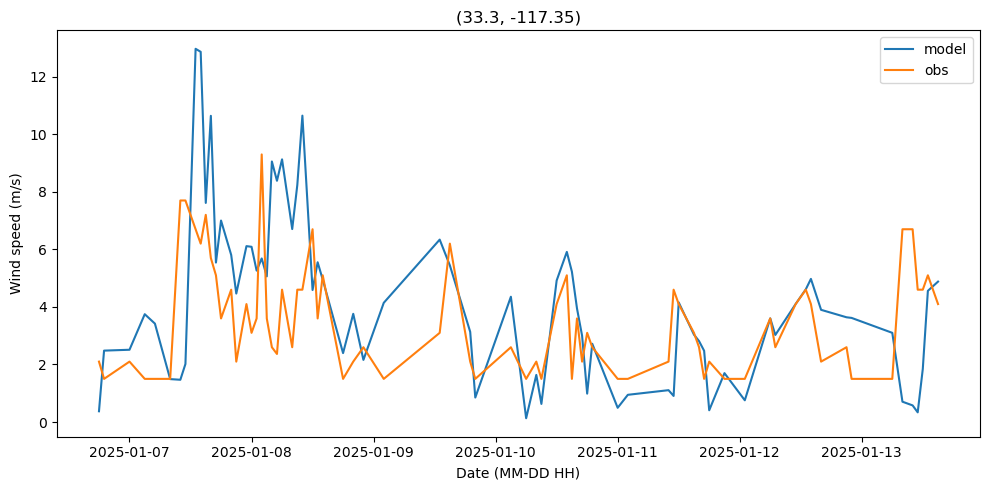

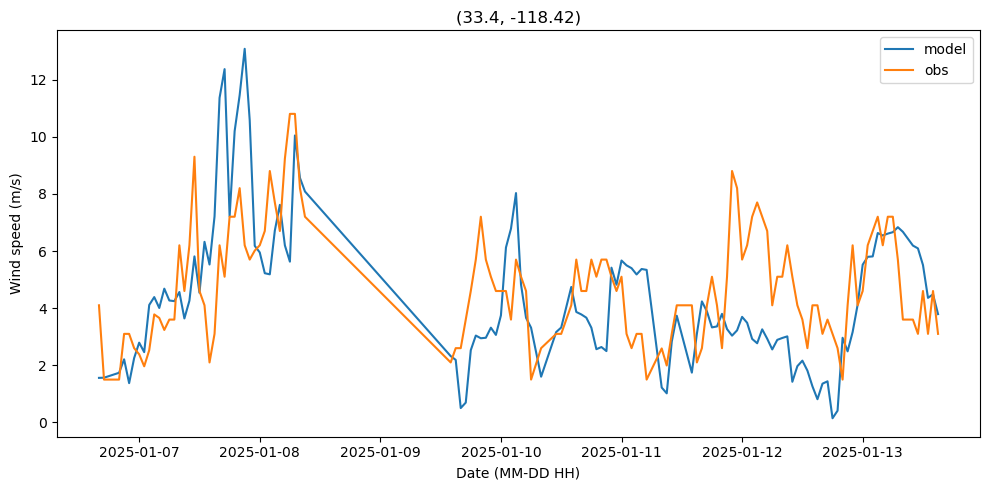

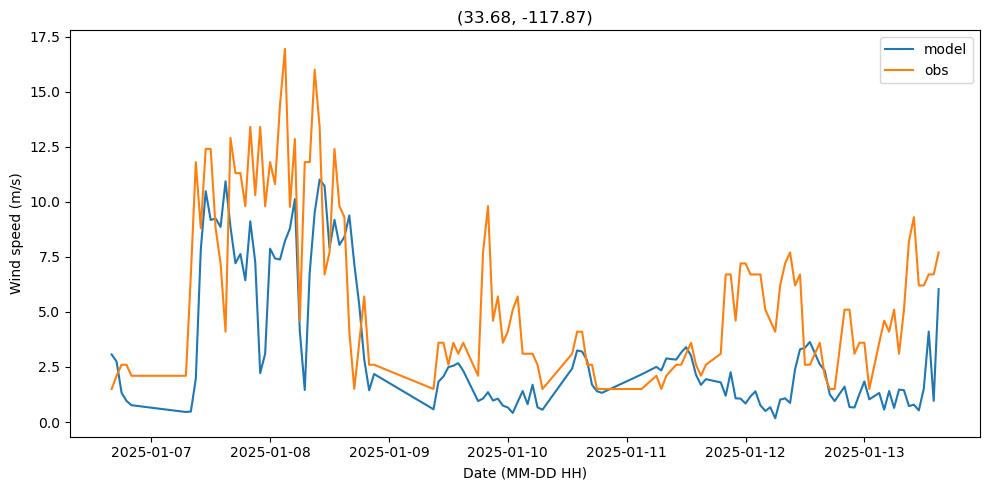

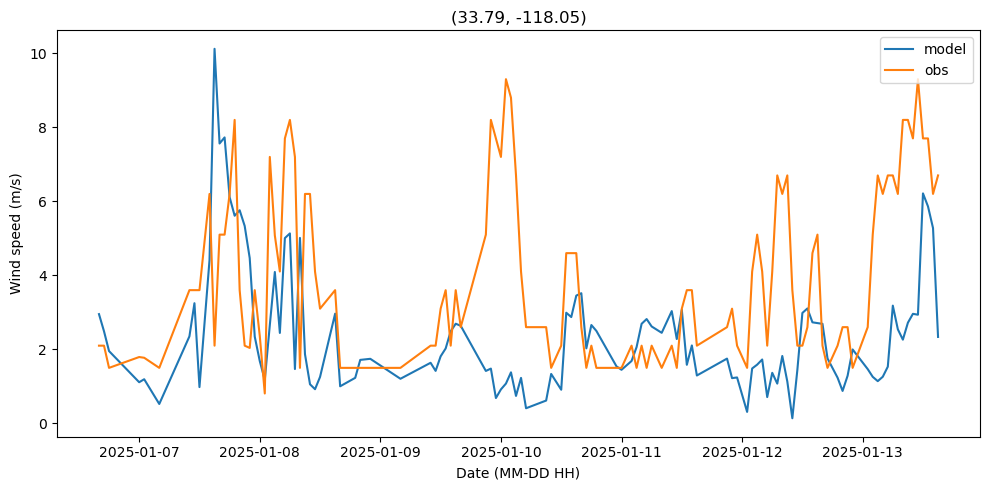

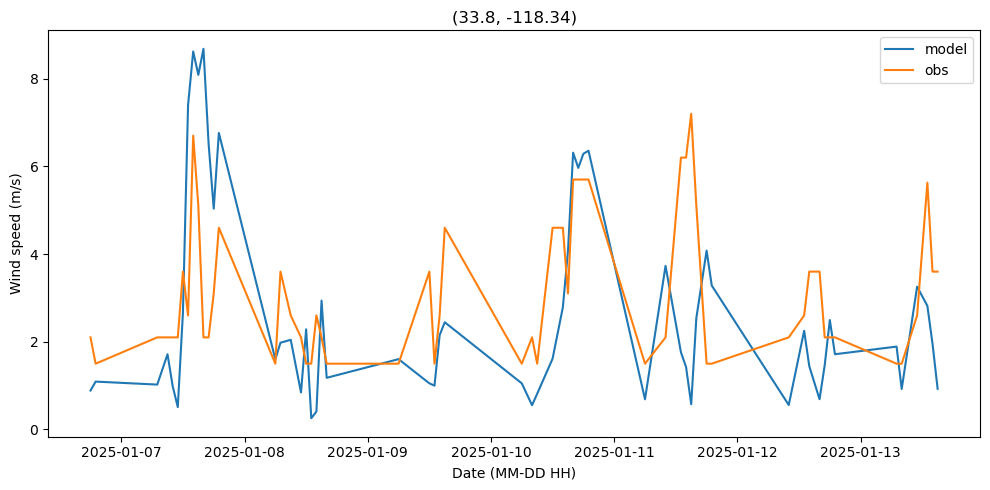

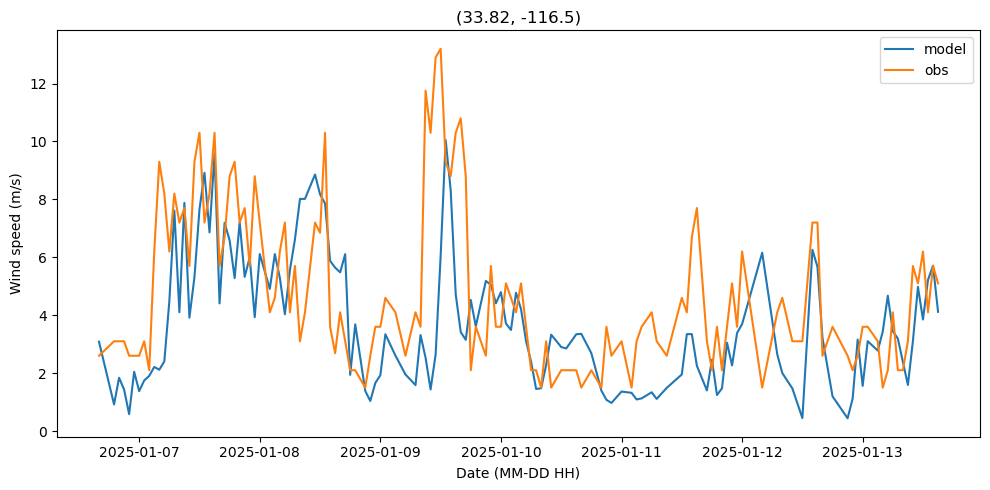

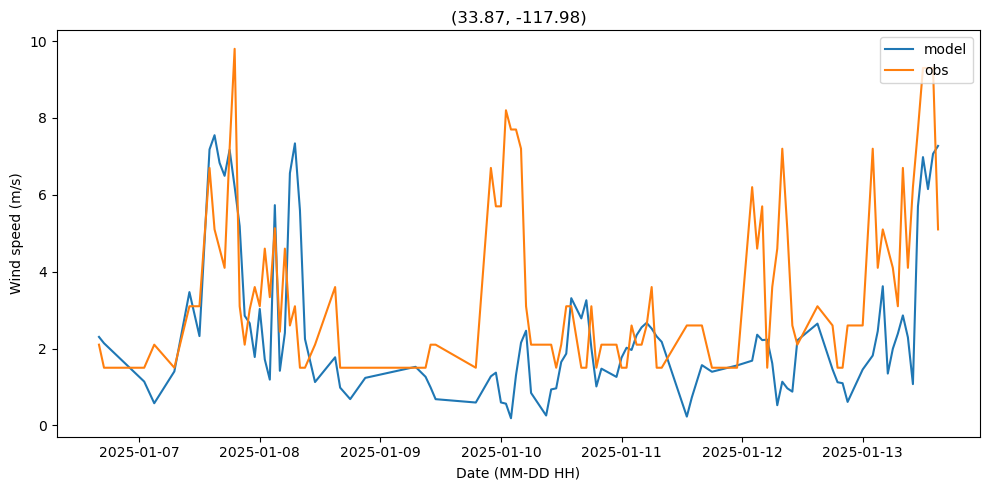

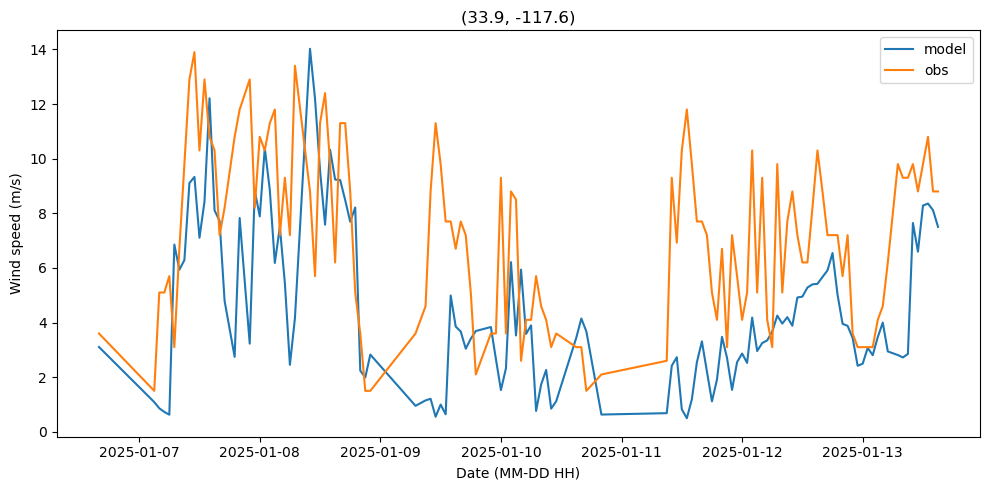

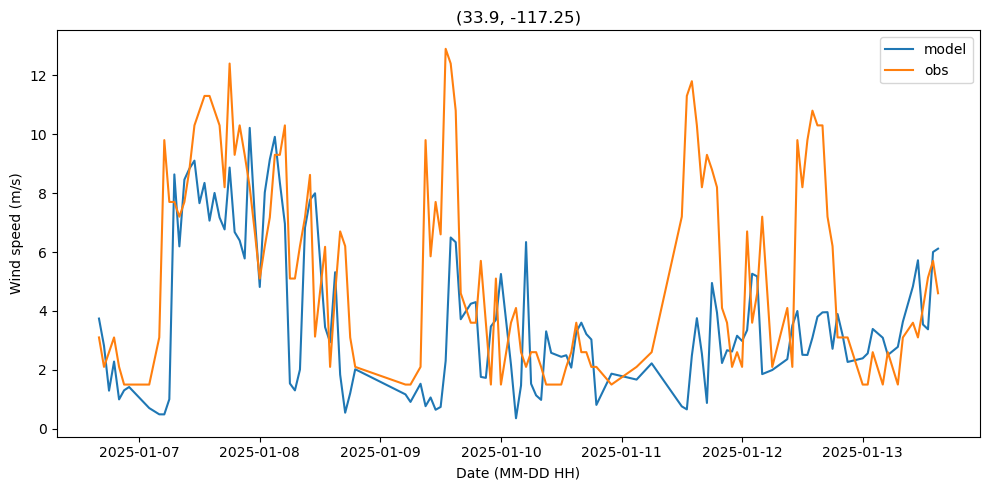

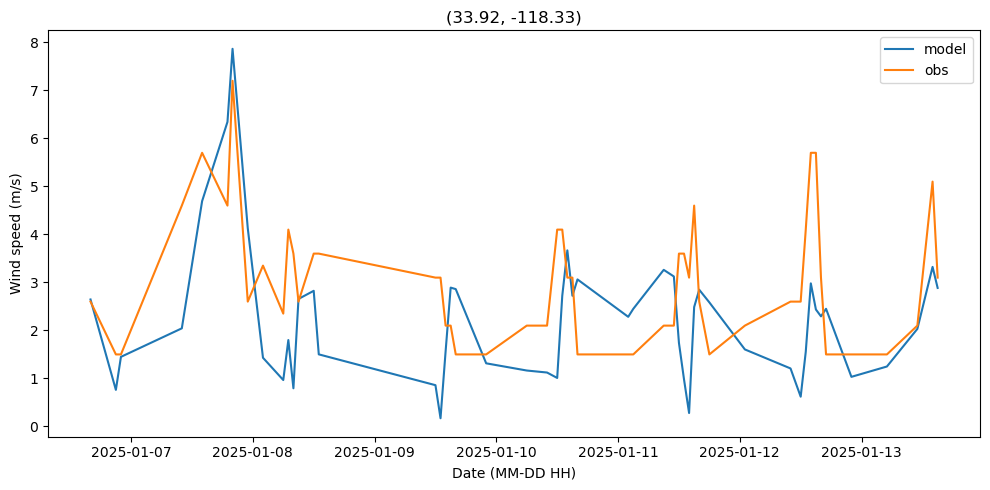

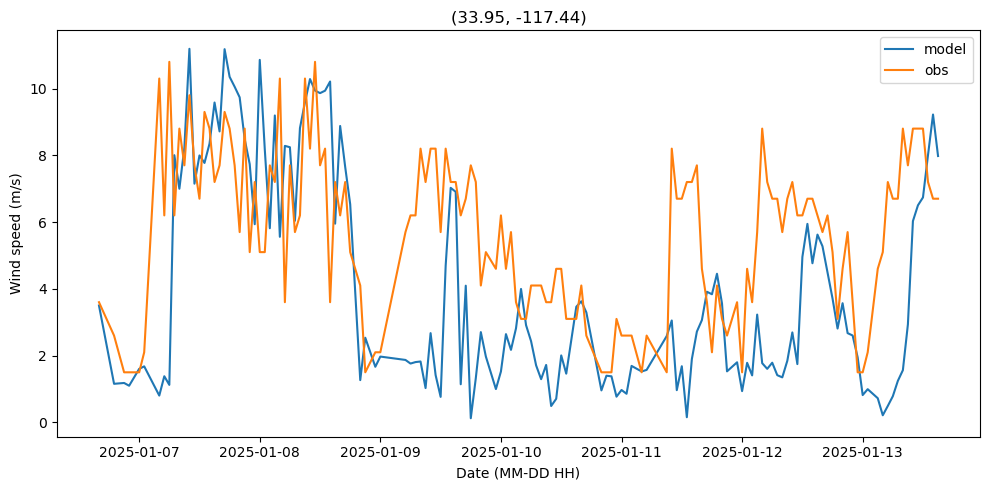

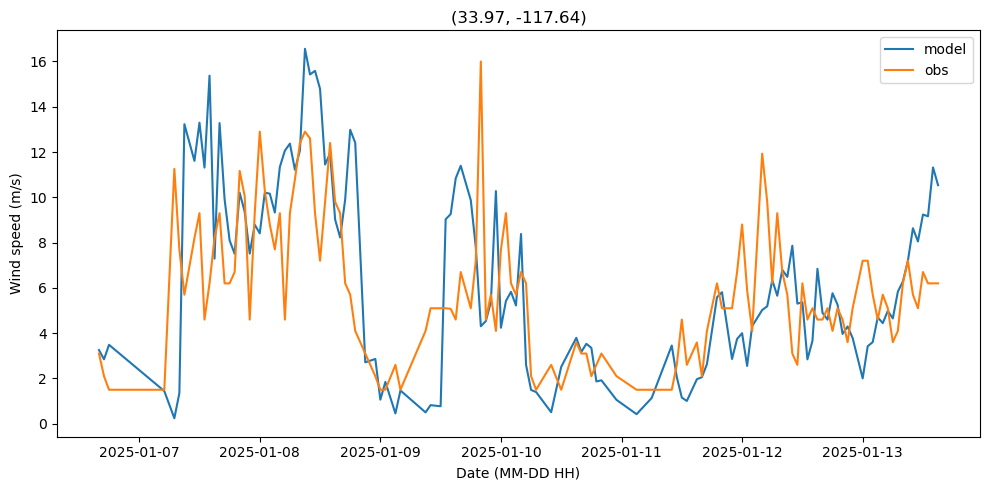

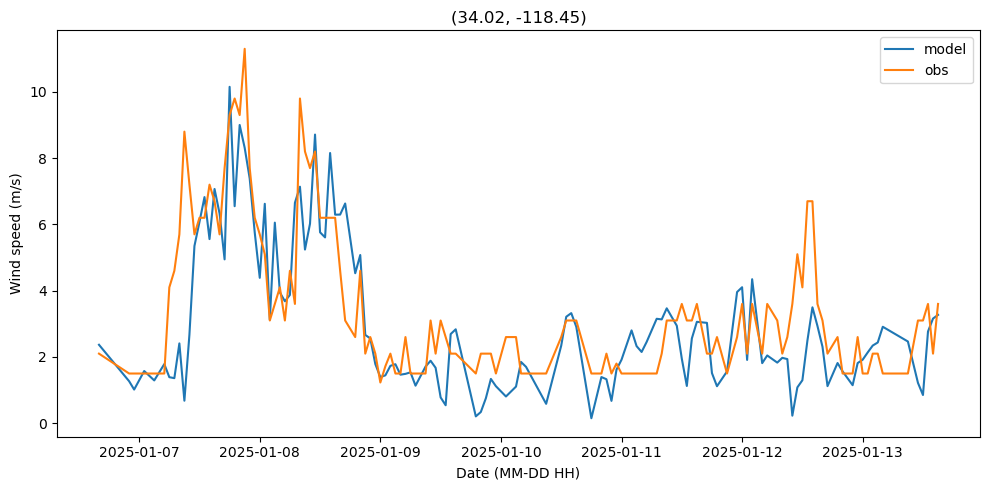

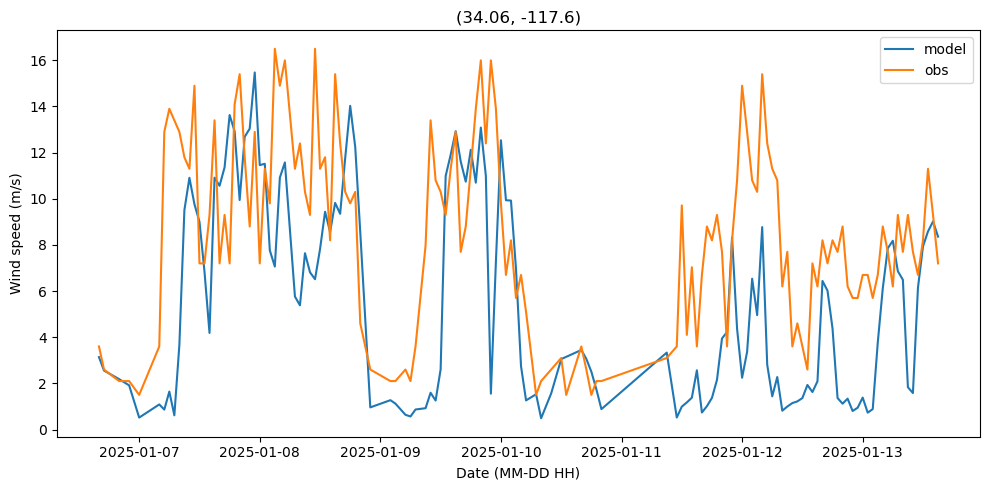

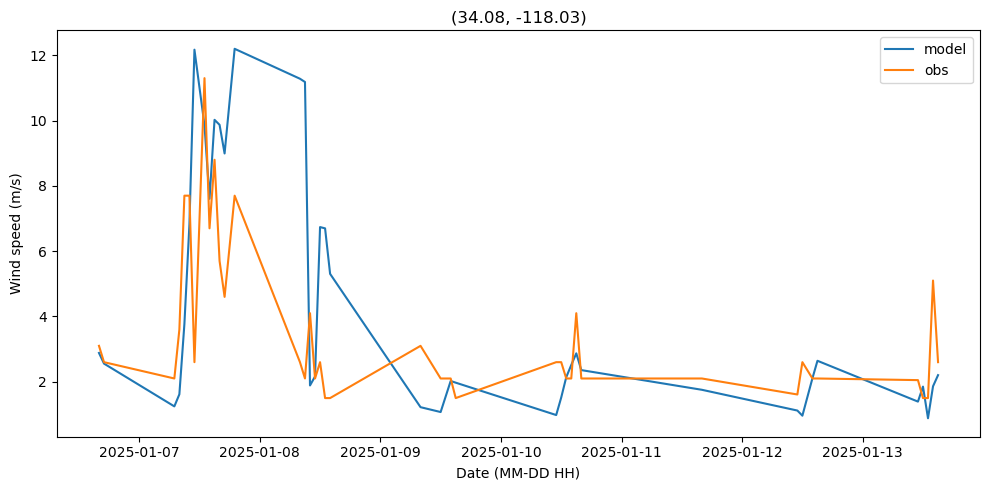

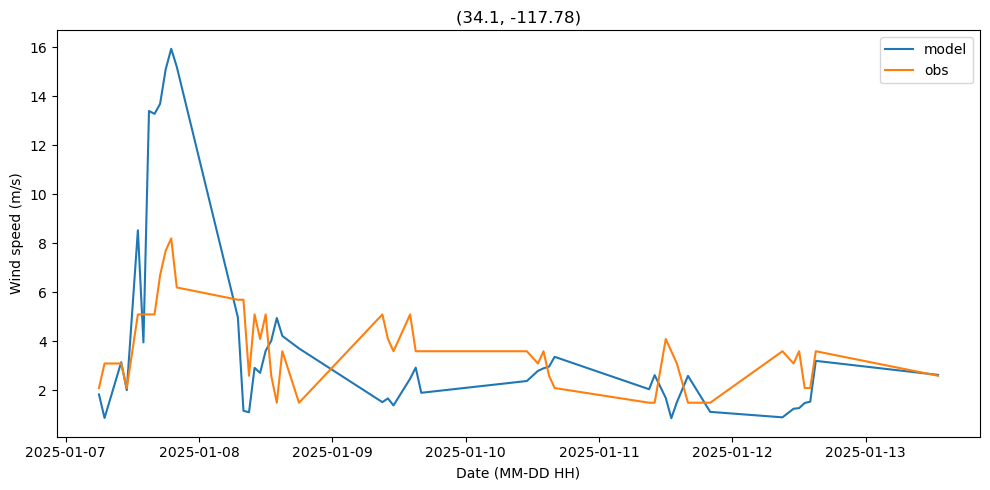

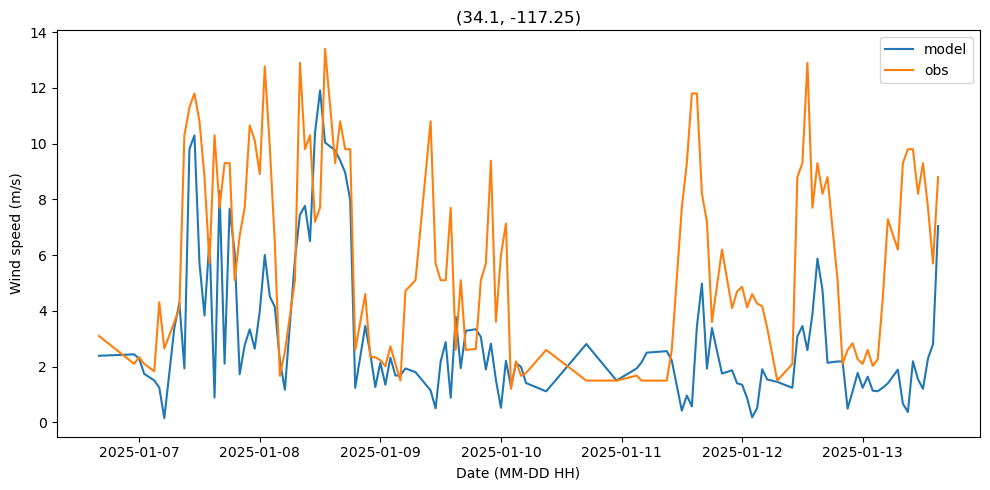

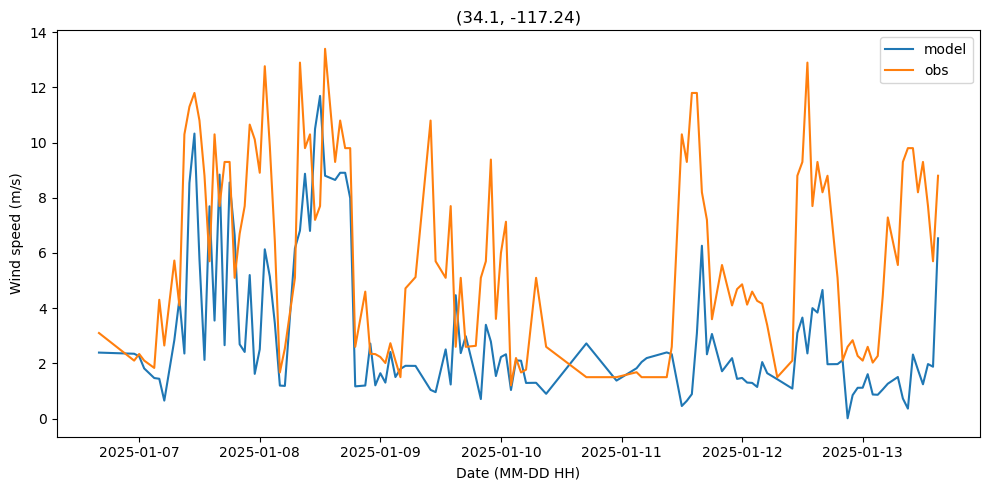

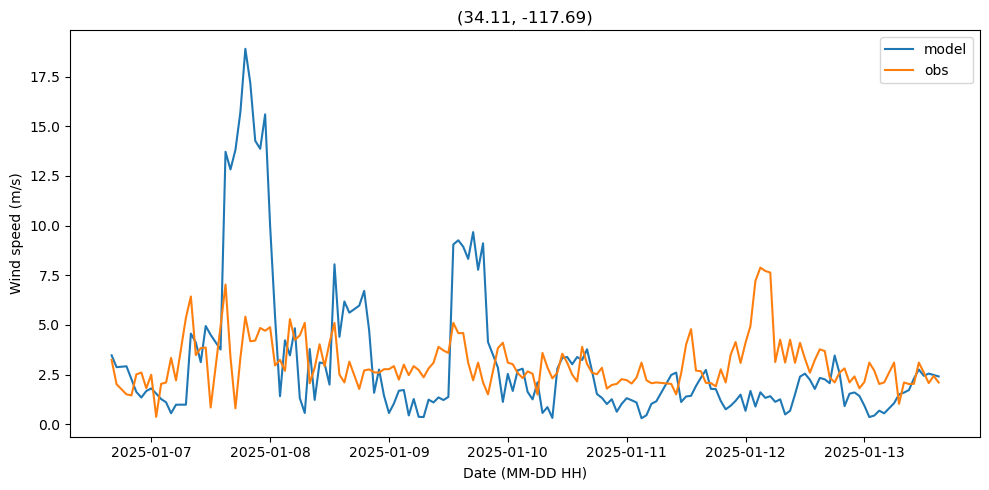

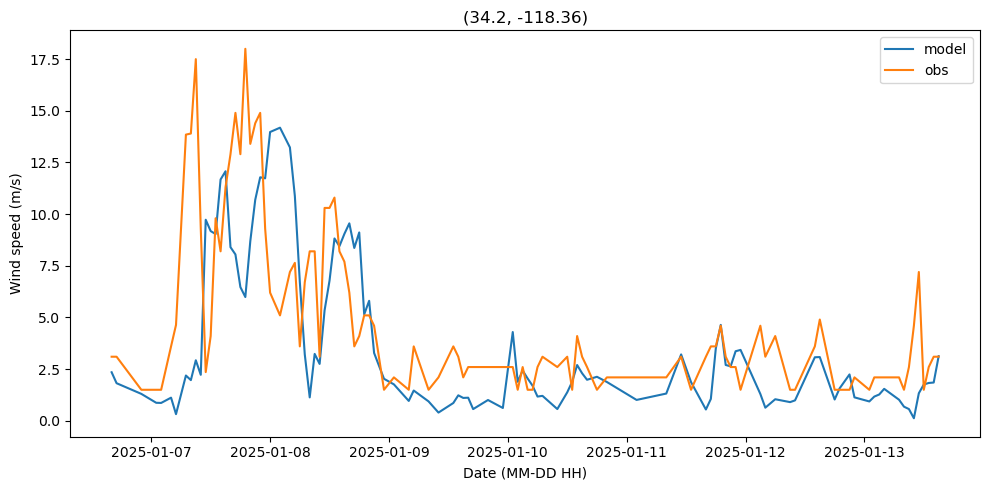

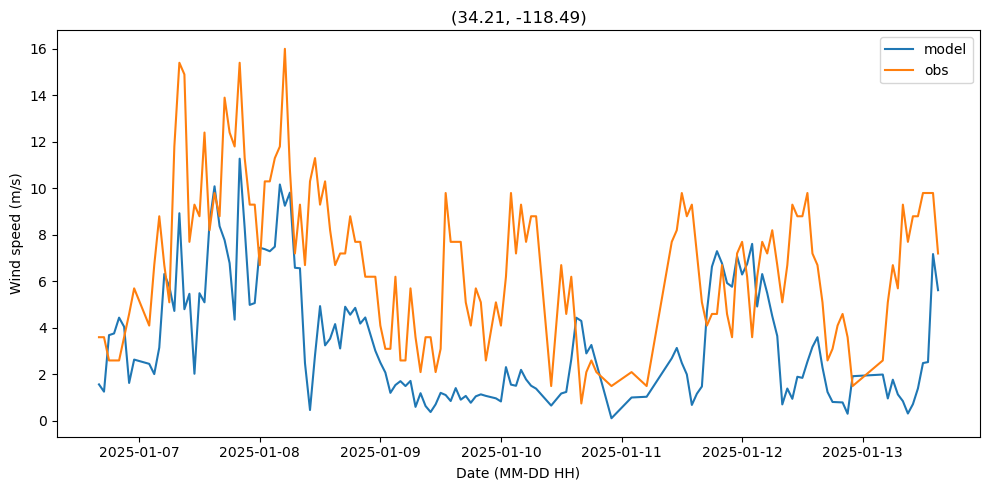

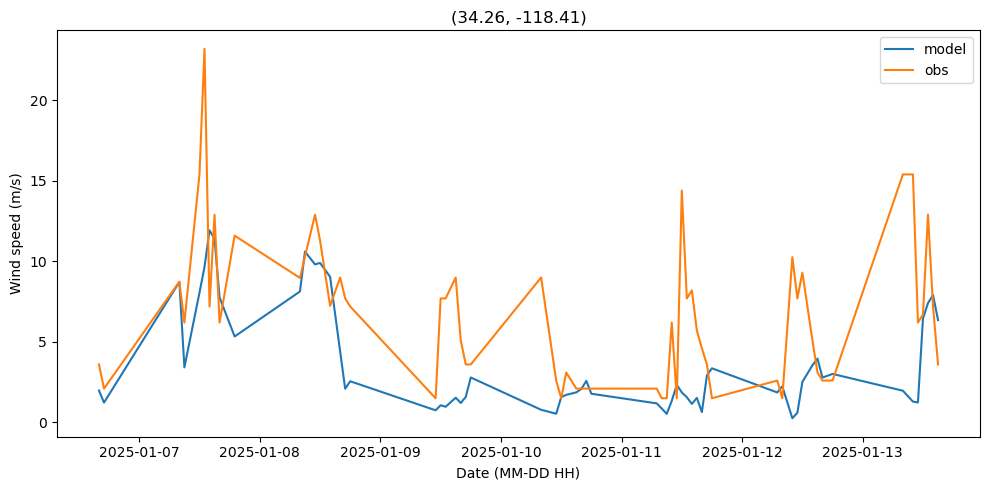

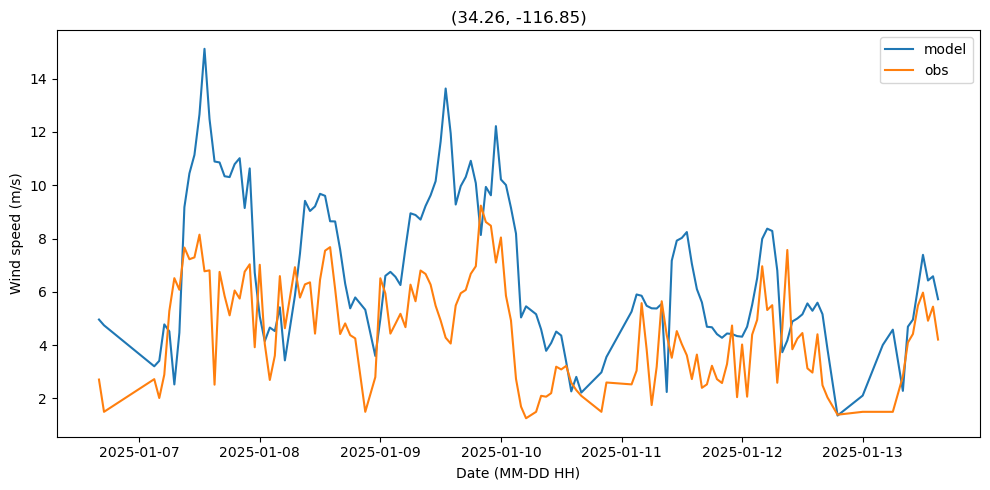

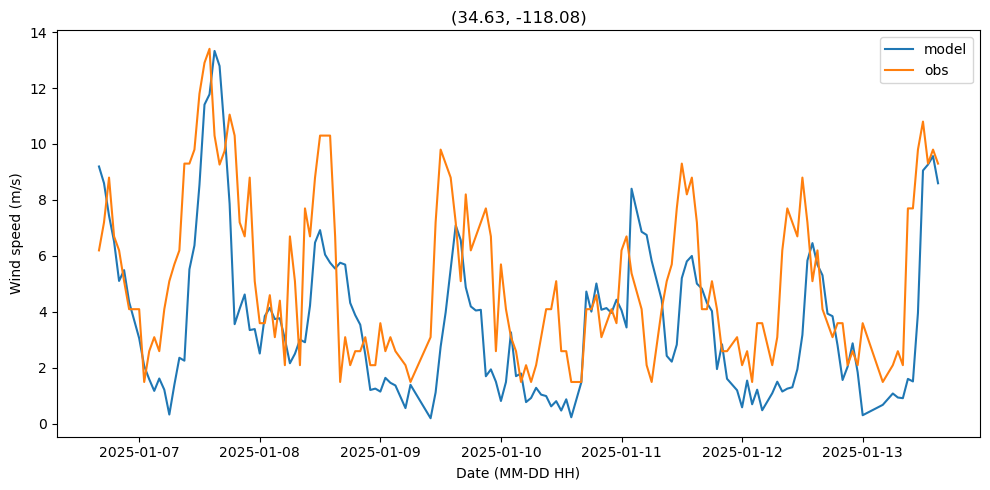

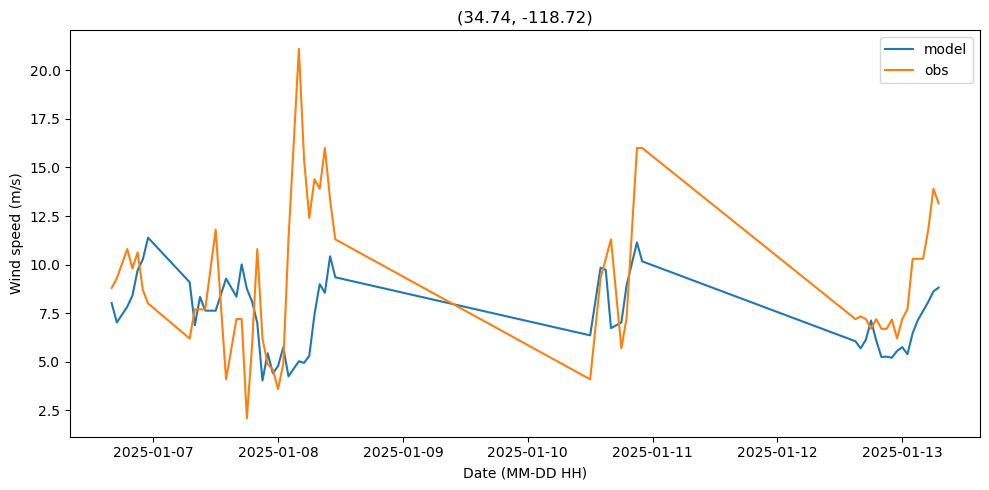

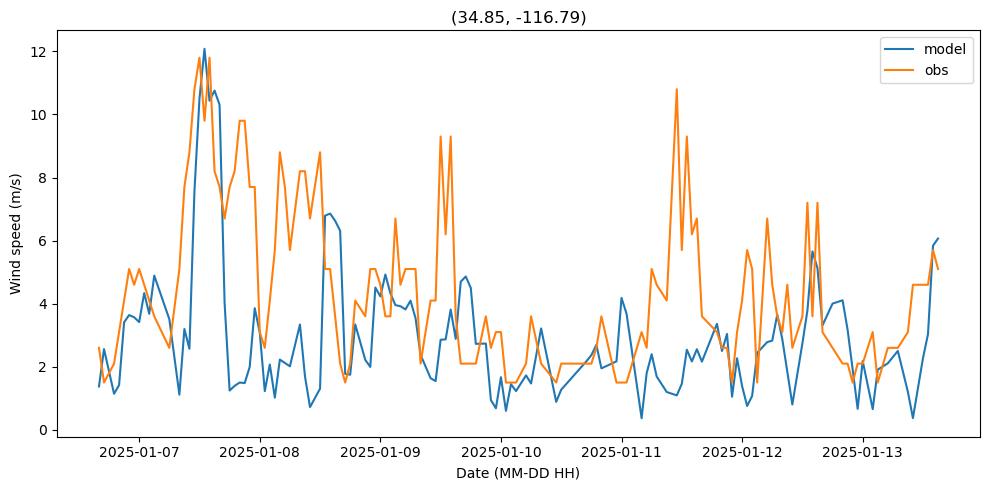

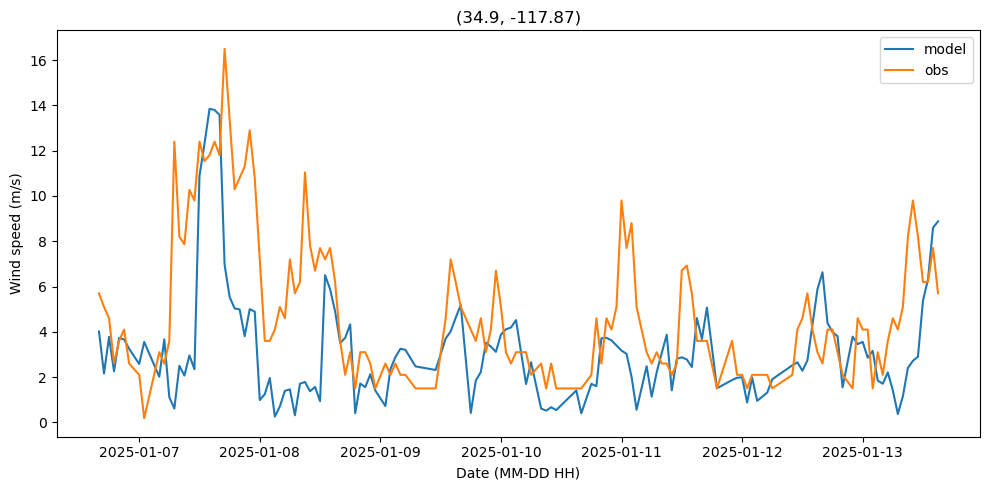

In [5]:
for group_name, group_df in df.groupby("location"):
    fig, ax = plt.subplots(figsize=[10, 5])
    plt.plot(group_df['date'], group_df['modws'], label='model')
    plt.plot(group_df['date'], group_df['obsws'], label='obs')
    ax.set_xlabel("Date (MM-DD HH)")
    ax.set_ylabel("Wind speed (m/s)")
    ax.set_title(group_name)
    ax.legend(loc="upper right")
    fig.tight_layout()
    #plt.savefig(f'tseries_wsp_d02_{group_name}.png', dpi=600)
    plt.show()

In [8]:
from scipy.stats import linregress 

metrics_list = []

for location, group in df.groupby('location'):
    obs = group['obsws']
    mod = group['modws']

    from sklearn.metrics import mean_absolute_error, root_mean_squared_error
    mae  = mean_absolute_error(obs, mod)
    rmse = root_mean_squared_error(obs, mod)

    slope, intercept, r_value, p_value, stderr = linregress(obs, mod)
    r2 = r_value ** 2

    corr  = obs.corr(mod)
    nrmse = rmse / np.mean(obs) if np.mean(obs) != 0 else np.nan

    metrics_list.append({
        'location'   : location,
        'MAE'        : mae,
        'RMSE'       : rmse,
        'R2'         : r2,
        'Correlation': corr,
        'nRMSE'      : nrmse
    })

metrics_df = pd.DataFrame(metrics_list)

metrics_df[['Latitude', 'Longitude']] = pd.DataFrame(
    metrics_df['location'].tolist(), index=metrics_df.index
)

metrics_df


,location,MAE,RMSE,R2,Correlation,nRMSE,Latitude,Longitude
0,"(33.3, -117.35)",2.064136,2.823953,0.146129,0.382268,0.807564,33.30,-117.35
1,"(33.4, -118.42)",1.877793,2.396313,0.209525,0.457739,0.502574,33.40,-118.42
2,"(33.68, -117.87)",3.033680,3.921130,0.378092,0.614892,0.678153,33.68,-117.87
3,"(33.79, -118.05)",2.210711,2.992381,0.035191,0.187593,0.761334,33.79,-118.05
4,"(33.8, -118.34)",1.694028,2.248555,0.148969,0.385966,0.723671,33.80,-118.34
5,"(33.82, -116.5)",1.947027,2.705040,0.251006,0.501005,0.565723,33.82,-116.50
6,"(33.87, -117.98)",1.833957,2.527282,0.168641,0.410659,0.701019,33.87,-117.98
7,"(33.9, -117.6)",3.211926,4.080169,0.214684,0.463340,0.575629,33.90,-117.60
8,"(33.9, -117.25)",2.558689,3.564719,0.207641,0.455676,0.653884,33.90,-117.25
9,"(33.92, -118.33)",1.337372,1.620054,0.207718,0.455761,0.536860,33.92,-118.33


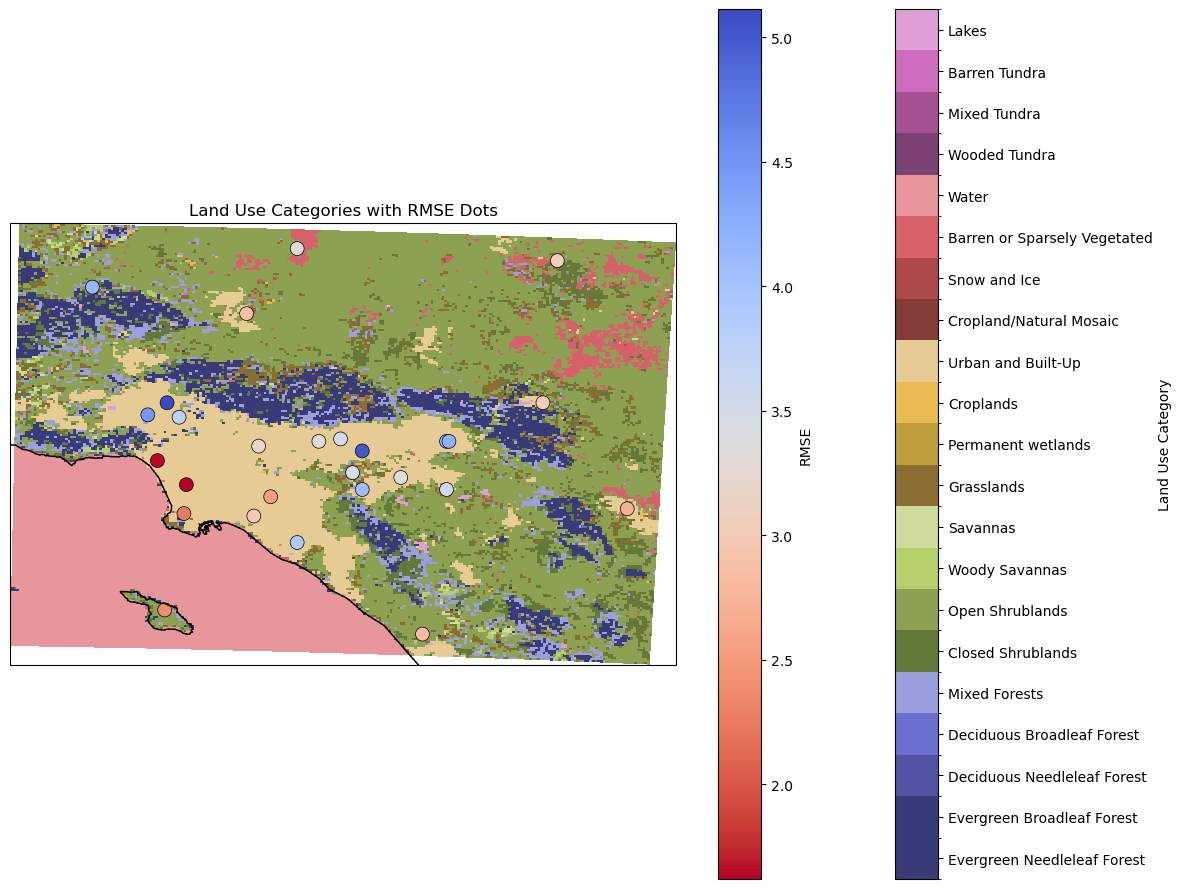

In [13]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap, BoundaryNorm

ds = xr.open_dataset('geo_em.d02.nc', engine='netcdf4')
lu_index = ds['LU_INDEX'].isel(Time=0)
lat = ds['XLAT_M'].isel(Time=0)
lon = ds['XLONG_M'].isel(Time=0)

land_use_labels = [
    'Evergreen Needleleaf Forest',     # 1
    'Evergreen Broadleaf Forest',      # 2
    'Deciduous Needleleaf Forest',     # 3
    'Deciduous Broadleaf Forest',      # 4
    'Mixed Forests',                   # 5
    'Closed Shrublands',               # 6
    'Open Shrublands',                 # 7
    'Woody Savannas',                  # 8
    'Savannas',                        # 9
    'Grasslands',                      # 10
    'Permanent wetlands',              # 11
    'Croplands',                       # 12
    'Urban and Built-Up',              # 13
    'Cropland/Natural Mosaic',         # 14
    'Snow and Ice',                    # 15
    'Barren or Sparsely Vegetated',    # 16
    'Water',                           # 17
    'Wooded Tundra',                   # 18
    'Mixed Tundra',                    # 19
    'Barren Tundra',                   # 20
    'Lakes'                            # 21
]


cmap = plt.get_cmap('tab20b', 22)
boundaries = np.arange(0.5, 22.5, 1)
norm = BoundaryNorm(boundaries, ncolors=21)


fig = plt.figure(figsize=(12, 9))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_title('Land Use Categories with RMSE Dots')


ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle=':')


mesh = ax.pcolormesh(lon, lat, lu_index, cmap=cmap, norm=norm,
                     transform=ccrs.PlateCarree(), shading='auto')

cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', ticks=np.arange(1, 22))
cbar.ax.set_yticklabels(land_use_labels)
cbar.set_label('Land Use Category')

sc = ax.scatter(metrics_df['Longitude'], metrics_df['Latitude'],
                c=metrics_df['RMSE'], cmap='coolwarm_r',
                s=100, edgecolors='black', linewidths=0.5,
                transform=ccrs.PlateCarree())

plt.colorbar(sc, ax=ax, orientation='vertical', label='RMSE')
plt.tight_layout()
#plt.savefig('Land Use with RMSE Dots, jan13-jan17.png', dpi=300)
plt.show()

In [14]:
import numpy as np
import pandas as pd

# Extract LU_INDEX and its lat/lon grid (2D arrays)
lu_index = ds['LU_INDEX'].isel(Time=0)
lat_grid = ds['XLAT_M'].isel(Time=0).values
lon_grid = ds['XLONG_M'].isel(Time=0).values

land_use_list = []
metrics_df[['Latitude', 'Longitude']] = pd.DataFrame(metrics_df['location'].tolist(), index=metrics_df.index)

for _, row in metrics_df.iterrows():
    lat_pt = row['Latitude']
    lon_pt = row['Longitude']

    distance_sq = (lat_grid - lat_pt)**2 + (lon_grid - lon_pt)**2

    iy, ix = np.unravel_index(np.argmin(distance_sq), distance_sq.shape)

    land_use_value = lu_index.values[iy, ix]
    land_use_list.append(land_use_value)

metrics_df['LandUseIndex'] = land_use_list

# As only these are used
land_use_mapping = {
    5: 'Mixed Forests',
    7: 'Open Shrublands',
    10: 'Grasslands',
    13: 'Urban and Built-Up',
    16: 'Barren or Sparsely Vegetated'
}


metrics_df['LandUseName'] = metrics_df['LandUseIndex'].map(land_use_mapping).fillna('Other')
metrics_df
#metrics_df.to_excel('metrics_with_landuse.xlsx', index=False)

,location,MAE,RMSE,R2,Correlation,nRMSE,Latitude,Longitude,LandUseIndex,LandUseName
0,"(33.3, -117.35)",2.064136,2.823953,0.146129,0.382268,0.807564,33.30,-117.35,7.0,Open Shrublands
1,"(33.4, -118.42)",1.877793,2.396313,0.209525,0.457739,0.502574,33.40,-118.42,5.0,Mixed Forests
2,"(33.68, -117.87)",3.033680,3.921130,0.378092,0.614892,0.678153,33.68,-117.87,13.0,Urban and Built-Up
3,"(33.79, -118.05)",2.210711,2.992381,0.035191,0.187593,0.761334,33.79,-118.05,13.0,Urban and Built-Up
4,"(33.8, -118.34)",1.694028,2.248555,0.148969,0.385966,0.723671,33.80,-118.34,13.0,Urban and Built-Up
5,"(33.82, -116.5)",1.947027,2.705040,0.251006,0.501005,0.565723,33.82,-116.50,13.0,Urban and Built-Up
6,"(33.87, -117.98)",1.833957,2.527282,0.168641,0.410659,0.701019,33.87,-117.98,13.0,Urban and Built-Up
7,"(33.9, -117.6)",3.211926,4.080169,0.214684,0.463340,0.575629,33.90,-117.60,13.0,Urban and Built-Up
8,"(33.9, -117.25)",2.558689,3.564719,0.207641,0.455676,0.653884,33.90,-117.25,13.0,Urban and Built-Up
9,"(33.92, -118.33)",1.337372,1.620054,0.207718,0.455761,0.536860,33.92,-118.33,13.0,Urban and Built-Up


In [15]:
metrics_df

,location,MAE,RMSE,R2,Correlation,nRMSE,Latitude,Longitude,LandUseIndex,LandUseName
0,"(33.3, -117.35)",2.064136,2.823953,0.146129,0.382268,0.807564,33.30,-117.35,7.0,Open Shrublands
1,"(33.4, -118.42)",1.877793,2.396313,0.209525,0.457739,0.502574,33.40,-118.42,5.0,Mixed Forests
2,"(33.68, -117.87)",3.033680,3.921130,0.378092,0.614892,0.678153,33.68,-117.87,13.0,Urban and Built-Up
3,"(33.79, -118.05)",2.210711,2.992381,0.035191,0.187593,0.761334,33.79,-118.05,13.0,Urban and Built-Up
4,"(33.8, -118.34)",1.694028,2.248555,0.148969,0.385966,0.723671,33.80,-118.34,13.0,Urban and Built-Up
5,"(33.82, -116.5)",1.947027,2.705040,0.251006,0.501005,0.565723,33.82,-116.50,13.0,Urban and Built-Up
6,"(33.87, -117.98)",1.833957,2.527282,0.168641,0.410659,0.701019,33.87,-117.98,13.0,Urban and Built-Up
7,"(33.9, -117.6)",3.211926,4.080169,0.214684,0.463340,0.575629,33.90,-117.60,13.0,Urban and Built-Up
8,"(33.9, -117.25)",2.558689,3.564719,0.207641,0.455676,0.653884,33.90,-117.25,13.0,Urban and Built-Up
9,"(33.92, -118.33)",1.337372,1.620054,0.207718,0.455761,0.536860,33.92,-118.33,13.0,Urban and Built-Up
